<a href="https://colab.research.google.com/github/evanssamwel/Zillow-Home-Value-Zestimate-Prediction-in-M/blob/main/Zillow_Home_Value_(Zestimate)_Prediction_in_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zillow Home Value (Zestimate) Prediction in ML

In this article, we will try to implement a house price index calculator which revolutionized the whole real estate industry in the US. This will be a regression task in which we have been provided with logarithm differences between the actual and the predicted prices of those homes by using a benchmark model.

Importing Libraries and Dataset
Python libraries make it easy for us to handle the data and perform typical and complex tasks with a single line of code.

Pandas - This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.
Numpy - Numpy arrays are very fast and can perform large computations in a very short time.
Matplotlib/Seaborn - This library is used to draw visualizations.
Sklearn - This module contains multiple libraries are having pre-implemented functions to perform tasks from data preprocessing to model development and evaluation.
XGBoost - This contains the eXtreme Gradient Boosting machine learning algorithm which is one of the algorithms which helps us to achieve high accuracy on predictions.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')
Now let's load the dataset into the panda's data frame and print its first five rows.


df = pd.read_csv('Zillow.csv')
df.head()
Output:

First five rows of the dataset.
First five rows of the dataset.
Now let's check the size of the dataset.


df.shape
Output:

(90275, 59)
The dataset contains too many features but we can observe that there are null values in the dataset as well. So, before performing any of the analyses let's first clean the data.


Data Cleaning
The data which is obtained from the primary sources is termed the raw data and required a lot of preprocessing before we can derive any conclusions from it or do some modeling on it. Those preprocessing steps are known as data cleaning and it includes, outliers removal, null value imputation, and removing discrepancies of any sort in the data inputs.


to_remove = []
for col in df.columns:

    # Removing columns having only one value.
    if df[col].nunique() == 1:
        to_remove.append(col)

    # Removing columns with more than 90% of the
    # rows as null values.
    elif (df[col].isnull()).mean() > 0.60:
        to_remove.append(col)

print(len(to_remove))
Output:

30
So, in total there are 30 columns that contain either unique values equal to 1 or have around 60% of the rows as null values.


df.drop(to_remove,
        axis=1,
        inplace=True)
Let's check which column of the dataset contains which type of data.


df.info()
Output:

Information regarding data in the columns
Information regarding data in the columns
Here we can see that there are still null values in different columns of the dataset. So, let's check for the null values in the data frame and impute them by using the mean value for the continuous variables and the mode value for the categorical columns.


df.isnull().sum().plot.bar()
plt.show()
Output:

Bar plot for the count of the number of null values in the columns
Bar plot for the count of the number of null values in the columns

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif df[col].dtype == np.number:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()
Output:

0
Exploratory Data Analysis
EDA is an approach to analyzing the data using visual techniques. It is used to discover trends, and patterns, or to check assumptions with the help of statistical summaries and graphical representations.


ints, objects, floats = [], [], []

for col in df.columns:
    if df[col].dtype == float:
        floats.append(col)
    elif df[col].dtype == int:
        ints.append(col)
    else:
        objects.append(col)

len(ints), len(floats), len(objects)
Output:

(1, 26, 2)

for col in objects:
    print(col, ' -> ', df[col].nunique())
    print(df[col].unique())
    print()
Output:

Unique value count as well as the unique values in the categorical columns
Unique value count as well as the unique values in the categorical columns
The number of unique values is too high to visualize else we could have plotted a count plot for these categorical columns.


plt.figure(figsize=(8, 5))
sb.distplot(df['target'])
plt.show()
Output:

Distribution plot for the target column
Distribution plot for the target column
From the above distribution plot of the target variable, it seems like there are outliers in the data. Let's use a boxplot to detect them.


plt.figure(figsize=(8, 5))
sb.boxplot(df['target'])
plt.show()
Output:

Box plot to detect outliers in the target column
Box plot to detect outliers in the target column
From the above box plot, we can clip the target values between -1 to 1 for feasible(only on patterns) training of the model.


print('Shape of the dataframe before removal of outliers', df.shape)
df = df[(df['target'] > -1) & (df['target'] < 1)]
print('Shape of the dataframe after removal of outliers ', df.shape)
Output:

Shape of the dataframe before removal of outliers (90275, 29)
Shape of the dataframe after removal of outliers  (89933, 29)
This means that we don't lose that many points.


for col in objects:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
Now let's check whether there are any highly correlated features in our dataset or not.


plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()
Output:

Heat map to find highly correlated features.
Heat map to find highly correlated features.
Certainly, there are some highly correlated features in the feature space. We will remove them to decrease the complexity of the data and avoid any cases of error.


to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']

df.drop(to_remove, axis=1, inplace=True)
Model Training
Now we will separate the features and target variables and split them into training and testing data by using which we will select the model which is performing best on the validation data.


features = df.drop(['parcelid'], axis=1)
target = df['target'].values

X_train, X_val,\
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.1,
                                      random_state=22)
X_train.shape, X_val.shape
Output:

(80939, 21), (8994, 21))
Normalizing the data before feeding it into machine learning models helps us to achieve stable and fast training.


# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
We have split our data into training and validation data also the normalization of the data has been done. Now let's train some state-of-the-art machine learning models and select the best out of them using the validation dataset.


from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(),
          Lasso(), RandomForestRegressor(), Ridge()]

for i in range(5):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()
Output:

LinearRegression() :
Training Error :  6.615973946852889e-17
Validation Error :  6.708349655426566e-17

XGBRegressor() :
Training Error :  0.0010633639062428474
Validation Error :  0.0010845248796474889

Lasso() :
Training Error :  0.06199753224405094
Validation Error :  0.06211054490276396

RandomForestRegressor() :
Training Error :  5.43384524155515e-06
Validation Error :  1.2540916166409197e-05

Ridge() :
Training Error :  7.705024690238485e-07
Validation Error :  7.729424066671234e-07
You may wonder the reason behind this low error value the reason behind this is the smaller target value. The target values are different between the logarithm of actual and the predicted house price values due to this all the values are already in the range of -1 to 1 so, this leads to even lower error values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
# prompt: upload dataset

from google.colab import files

uploaded = files.upload()

Saving Zillow.csv to Zillow.csv


In [3]:
df = pd.read_csv('Zillow.csv')
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,485713.0,1023282.0,2016.0,537569.0,11013.72,NaN,NaN,6.059063e+13,0.025595
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,88000.0,464000.0,2016.0,376000.0,5672.48,NaN,NaN,6.111001e+13,0.055619
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,85289.0,564778.0,2016.0,479489.0,6488.30,NaN,NaN,6.059022e+13,0.005383
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,108918.0,145143.0,2016.0,36225.0,1777.51,NaN,NaN,6.037300e+13,-0.103410
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,73681.0,119407.0,2016.0,45726.0,1533.89,NaN,NaN,6.037124e+13,0.006940


In [4]:
df.shape

(77613, 59)

In [5]:
to_remove = []
for col in df.columns:

    # Removing columns having only one value.
    if df[col].nunique() == 1:
        to_remove.append(col)

    # Removing columns with more than 90% of the
    # rows as null values.
    elif (df[col].isnull()).mean() > 0.60:
        to_remove.append(col)

print(len(to_remove))

30


In [6]:
df.drop(to_remove,
        axis=1,
        inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   buildingqualitytypeid         49809 non-null  float64
 4   calculatedbathnbr             76963 non-null  float64
 5   calculatedfinishedsquarefeet  77378 non-null  float64
 6   finishedsquarefeet12          73923 non-null  float64
 7   fips                          77579 non-null  float64
 8   fullbathcnt                   76963 non-null  float64
 9   heatingorsystemtypeid         49571 non-null  float64
 10  latitude                      77579 non-null  float64
 11  longitude                     77579 non-null  float64
 12  lotsizesquarefeet             69321 non-null  float64
 13  p

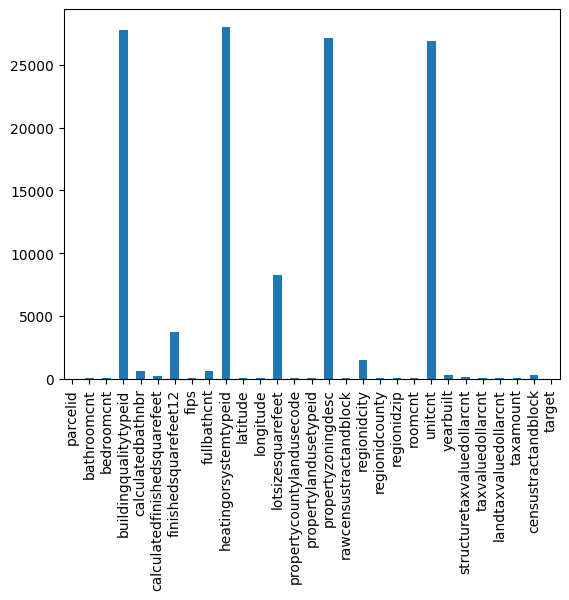

In [8]:
df.isnull().sum().plot.bar()
plt.show()

In [9]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif df[col].dtype == np.number:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

np.int64(0)

In [10]:
ints, objects, floats = [], [], []

for col in df.columns:
    if df[col].dtype == float:
        floats.append(col)
    elif df[col].dtype == int:
        ints.append(col)
    else:
        objects.append(col)

len(ints), len(floats), len(objects)

(1, 26, 2)

In [11]:
for col in objects:
    print(col, ' -> ', df[col].nunique())
    print(df[col].unique())
    print()

propertycountylandusecode  ->  75
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']

propertyzoningdesc  ->  1907
['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']



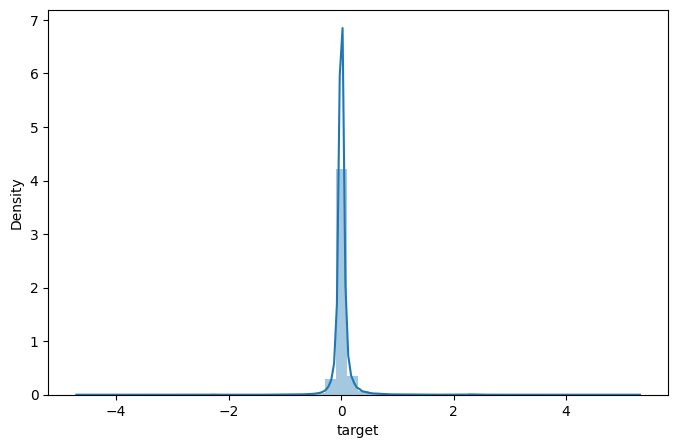

In [12]:
plt.figure(figsize=(8, 5))
sb.distplot(df['target'])
plt.show()

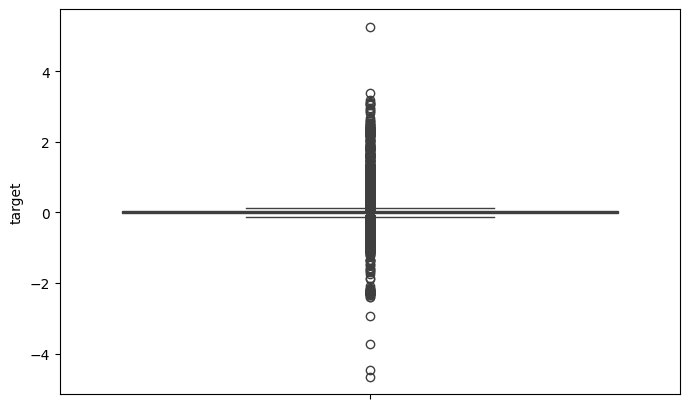

In [13]:
plt.figure(figsize=(8, 5))
sb.boxplot(df['target'])
plt.show()

In [14]:
print('Shape of the dataframe before removal of outliers', df.shape)
df = df[(df['target'] > -1) & (df['target'] < 1)]
print('Shape of the dataframe after removal of outliers ', df.shape)

Shape of the dataframe before removal of outliers (77613, 29)
Shape of the dataframe after removal of outliers  (77261, 29)


In [15]:
for col in objects:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

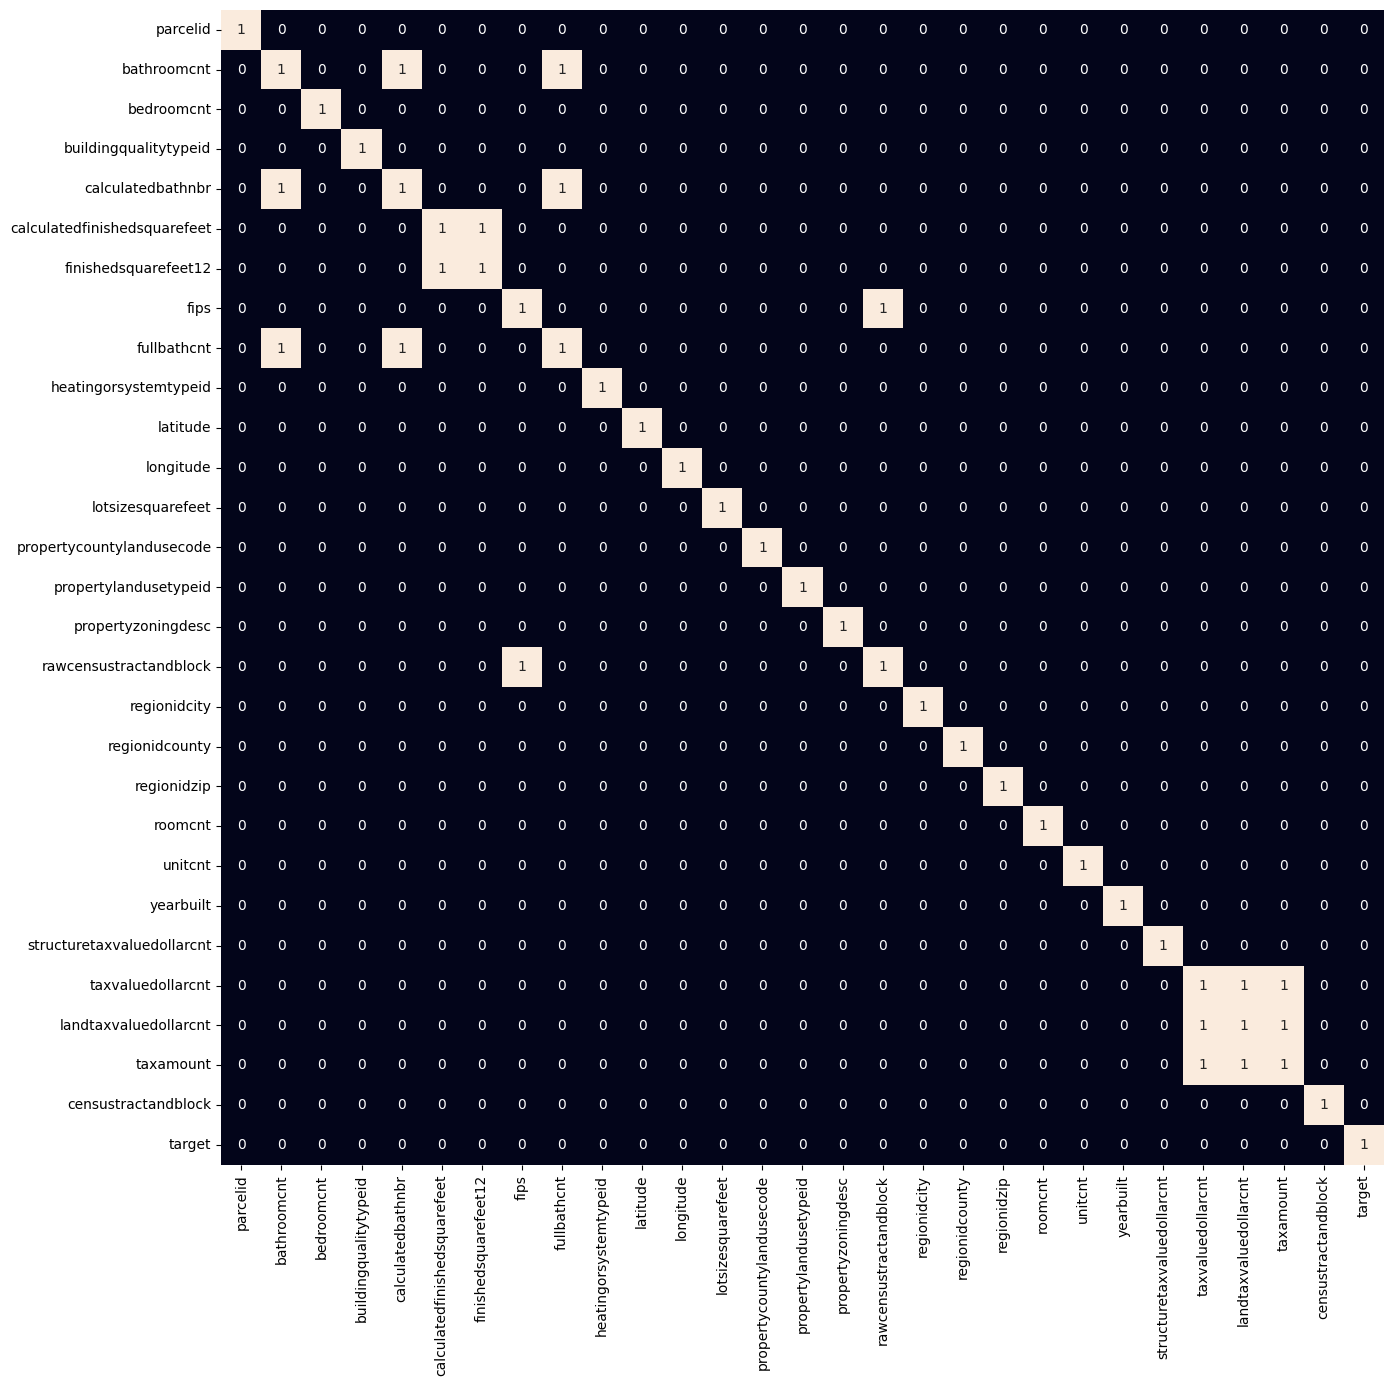

In [16]:
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [17]:
to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']

df.drop(to_remove, axis=1, inplace=True)

In [18]:
features = df.drop(['parcelid'], axis=1)
target = df['target'].values

X_train, X_val,\
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.1,
                                      random_state=22)
X_train.shape, X_val.shape

((69534, 21), (7727, 21))

In [19]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [20]:
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(),
          Lasso(), RandomForestRegressor(), Ridge()]

for i in range(5):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() : 
Training Error :  6.613582324692388e-17
Validation Error :  6.513267822759478e-17

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) : 
Training Error :  0.0011615510279198217
Validation Error :  0.0020190995111265897

Lasso() : 
Training Error :  0.06232063320274573
Validation Er